In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount("/content/drive")
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
from matplotlib.cm import get_cmap
import seaborn as sns

Mounted at /content/drive


In [2]:
sdss = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/STA437/SDSS/sdss_data.csv")

print(f"Objects: {len(sdss)}, Variables: {sdss.shape[1]}")
print(f"Classes: {sdss['class'].value_counts().to_dict()}")
# Photometric features for multivariate analysis
photo_cols = ['u', 'g', 'r', 'i', 'z']
X = sdss[photo_cols].values
y = sdss['class'].values

Objects: 10000, Variables: 15
Classes: {'GALAXY': 4998, 'STAR': 4152, 'QSO': 850}


In [3]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10

EDA

In [4]:
sdss.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ra,10000.0,NaN,NaN,NaN,175.529987,47.783439,8.2351,157.370946,180.394514,201.547279,260.884382
dec,10000.0,NaN,NaN,NaN,14.836148,25.212207,-5.382632,-0.539035,0.404166,35.649397,68.542265
u,10000.0,NaN,NaN,NaN,18.619355,0.828656,12.98897,18.178035,18.853095,19.259232,19.5999
g,10000.0,NaN,NaN,NaN,17.371931,0.945457,12.79955,16.8151,17.495135,18.010145,19.91897
r,10000.0,NaN,NaN,NaN,16.840963,1.067764,12.4316,16.173333,16.85877,17.512675,24.80204
i,10000.0,NaN,NaN,NaN,16.583579,1.141805,11.94721,15.853705,16.554985,17.25855,28.17963
z,10000.0,NaN,NaN,NaN,16.422833,1.203188,11.61041,15.618285,16.389945,17.141447,22.83306
run,10000.0,NaN,NaN,NaN,981.0348,273.305024,308.0,752.0,756.0,1331.0,1412.0
camcol,10000.0,NaN,NaN,NaN,3.6487,1.666183,1.0,2.0,4.0,5.0,6.0
field,10000.0,NaN,NaN,NaN,302.3801,162.577763,11.0,184.0,299.0,414.0,768.0


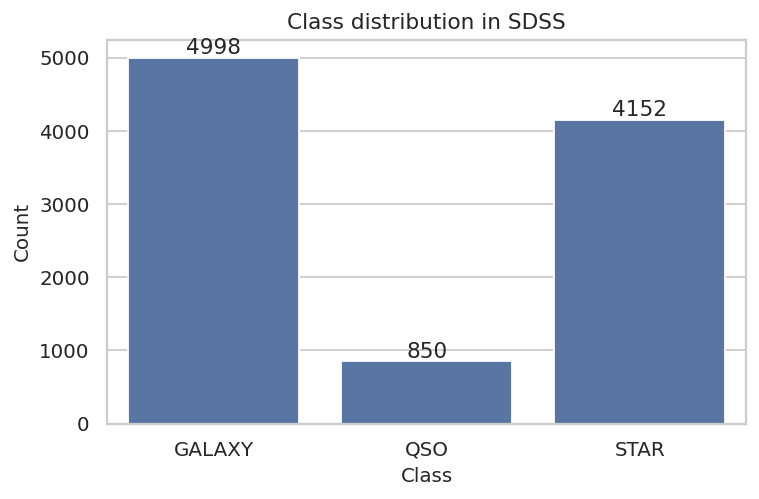

In [5]:
class_counts = sdss['class'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x=class_counts.index, y=class_counts.values)
ax.set_title("Class distribution in SDSS")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

for i, v in enumerate(class_counts.values):
    ax.text(i, v + 50, str(v), ha='center')

plt.tight_layout()
plt.show()

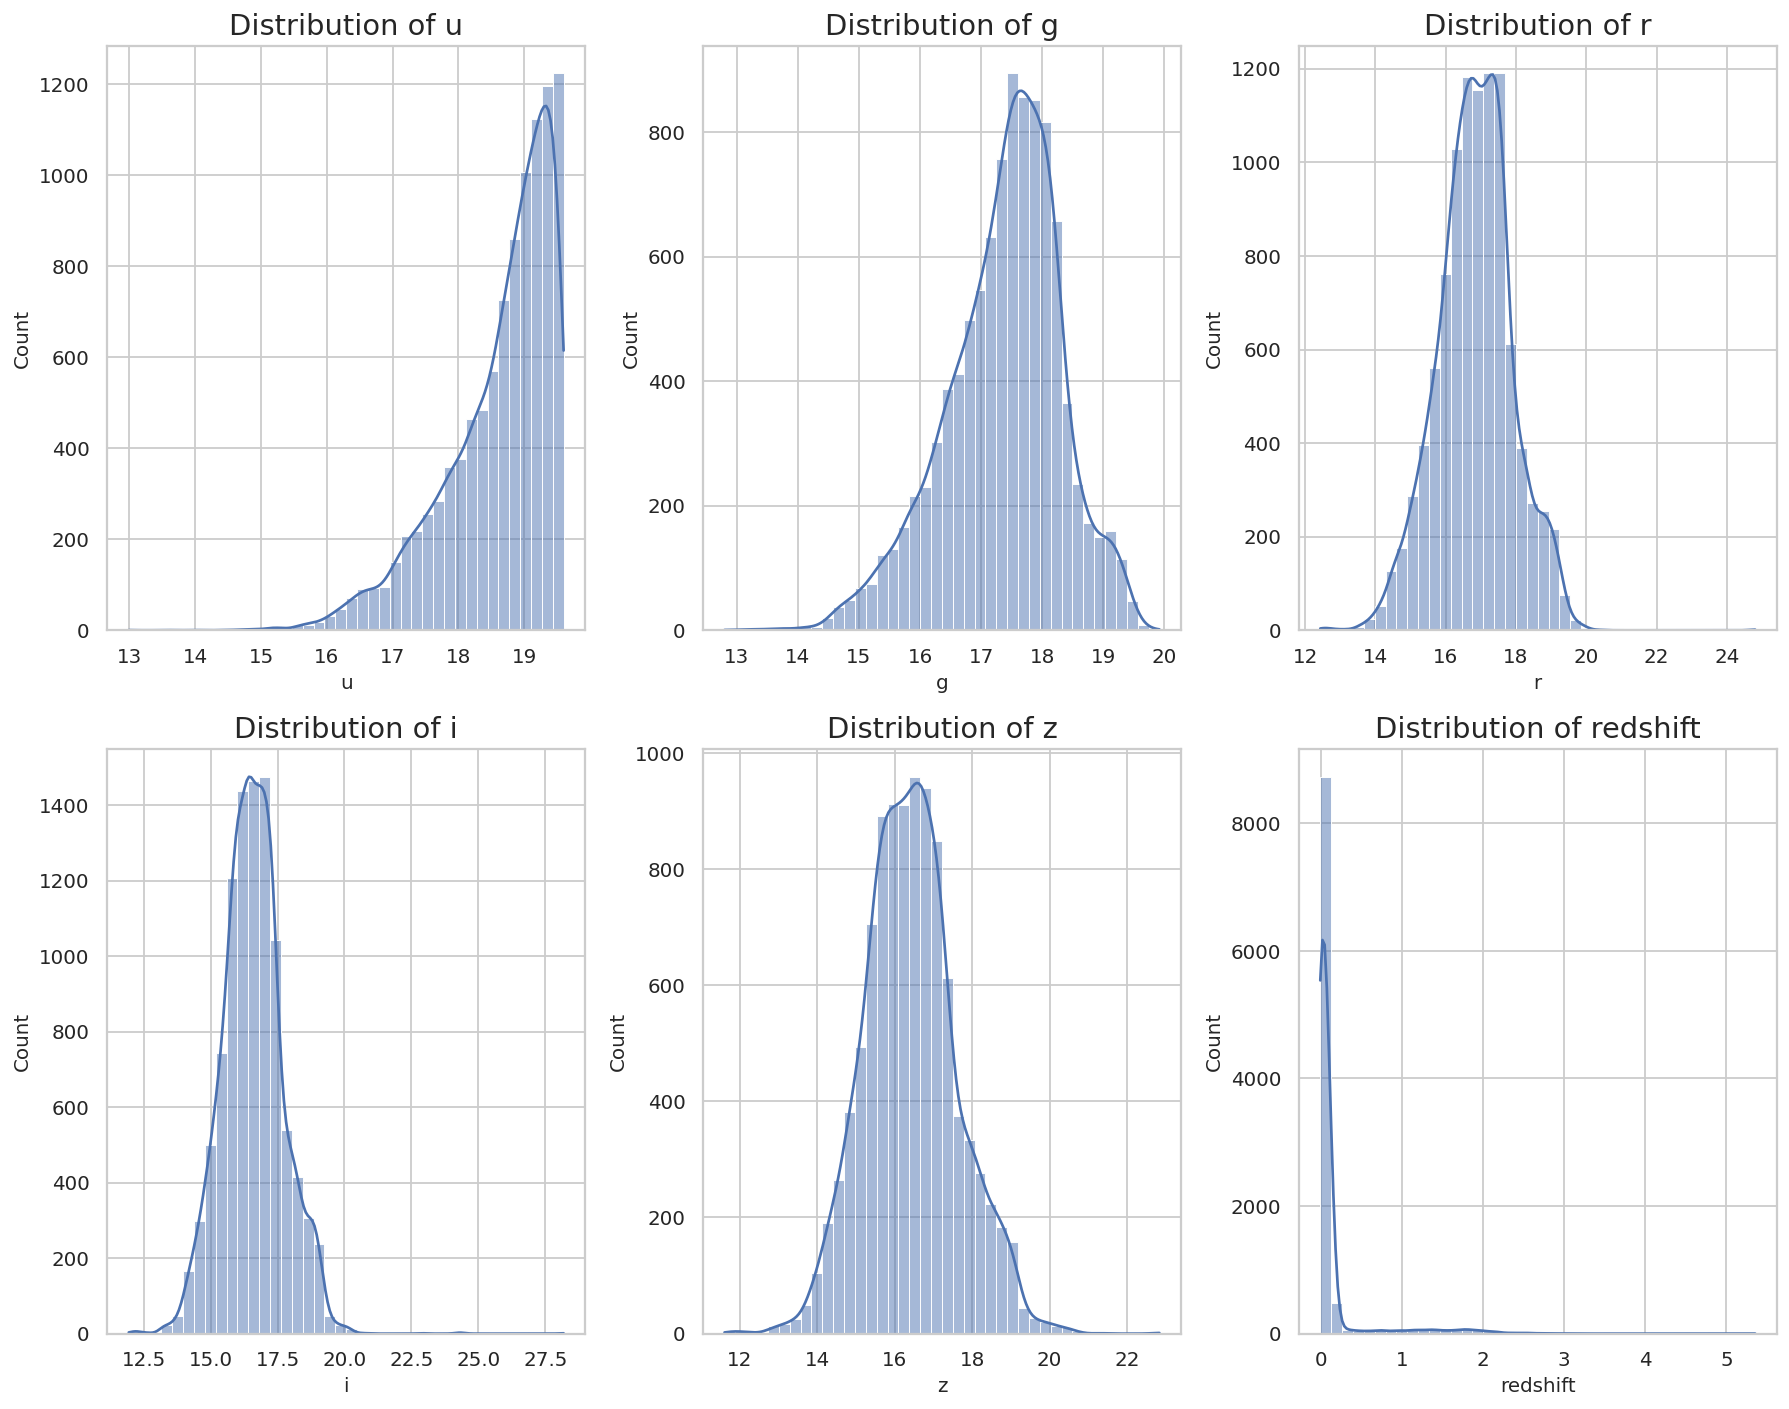

In [6]:
eda_num_cols = ['u', 'g', 'r', 'i', 'z', 'redshift']

fig, axes = plt.subplots(2, 3, figsize=(14, 11))
axes = axes.flatten()

for ax, col in zip(axes, eda_num_cols):
    sns.histplot(sdss[col], bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}", fontsize=16)

plt.tight_layout()
plt.show()

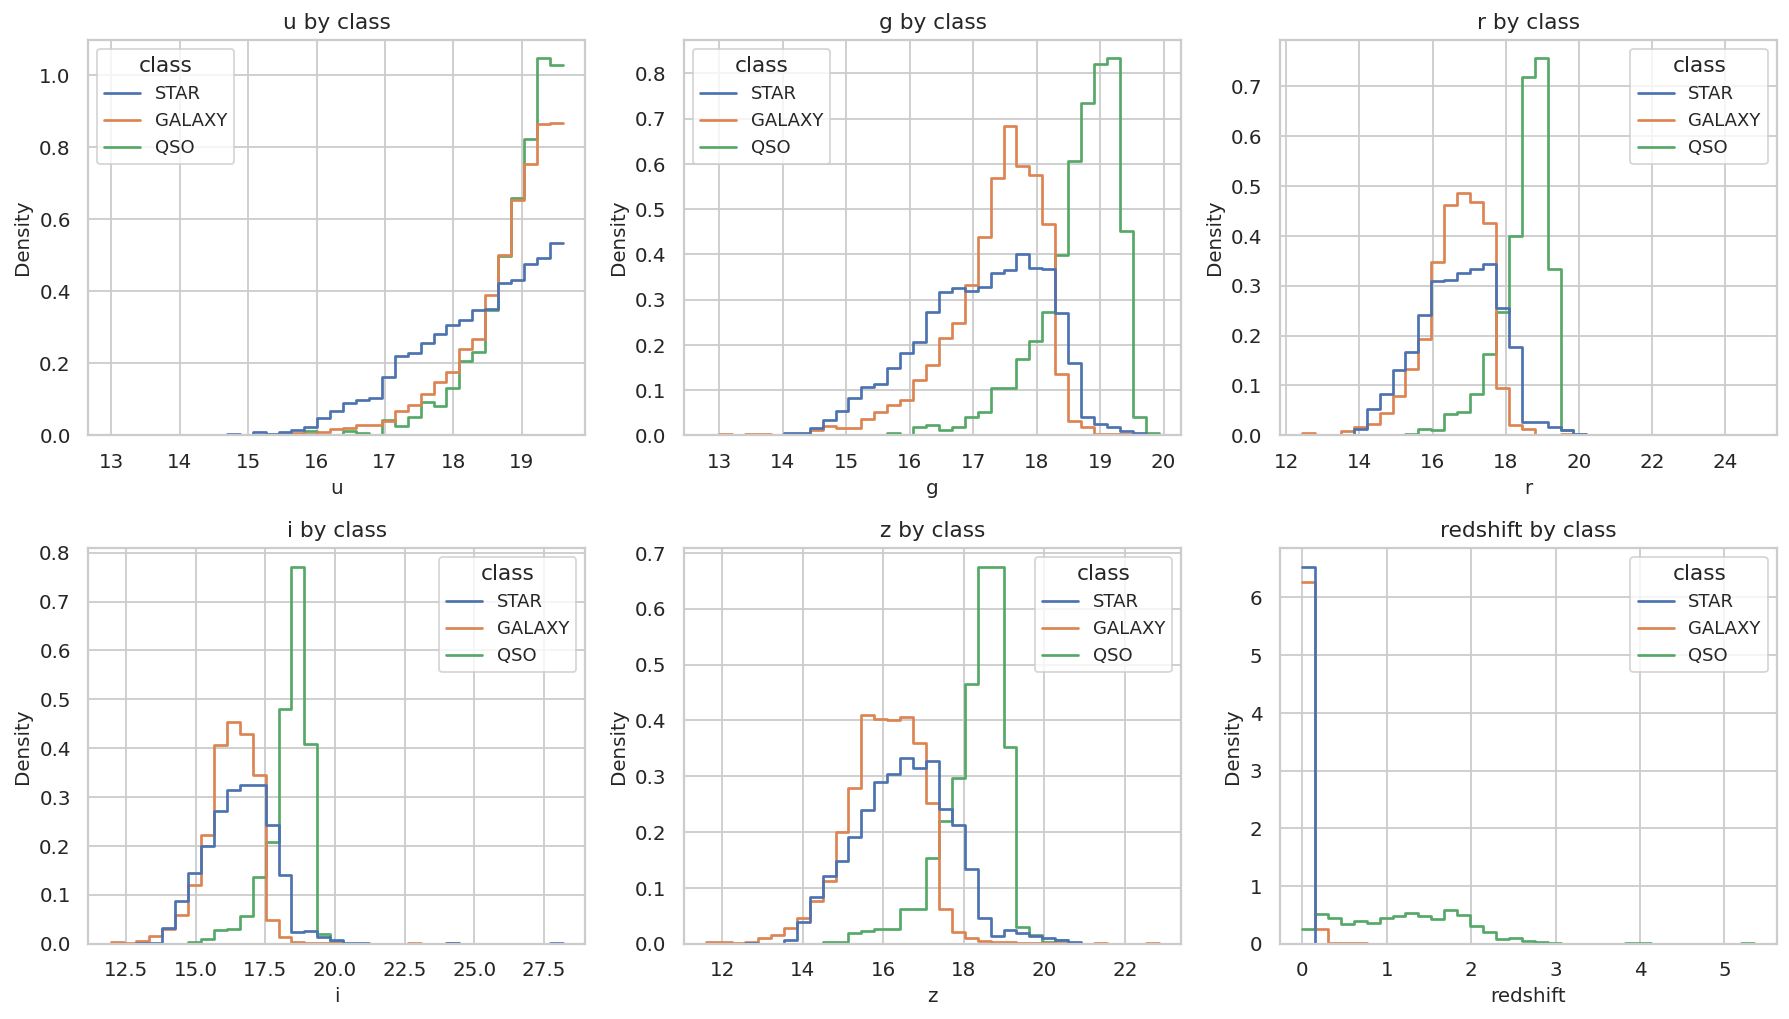

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, eda_num_cols):
    sns.histplot(
        data=sdss, x=col, hue='class',
        bins=35, stat='density', common_norm=False,
        element='step', fill=False, ax=ax
    )
    ax.set_title(f"{col} by class")

plt.tight_layout()
plt.show()

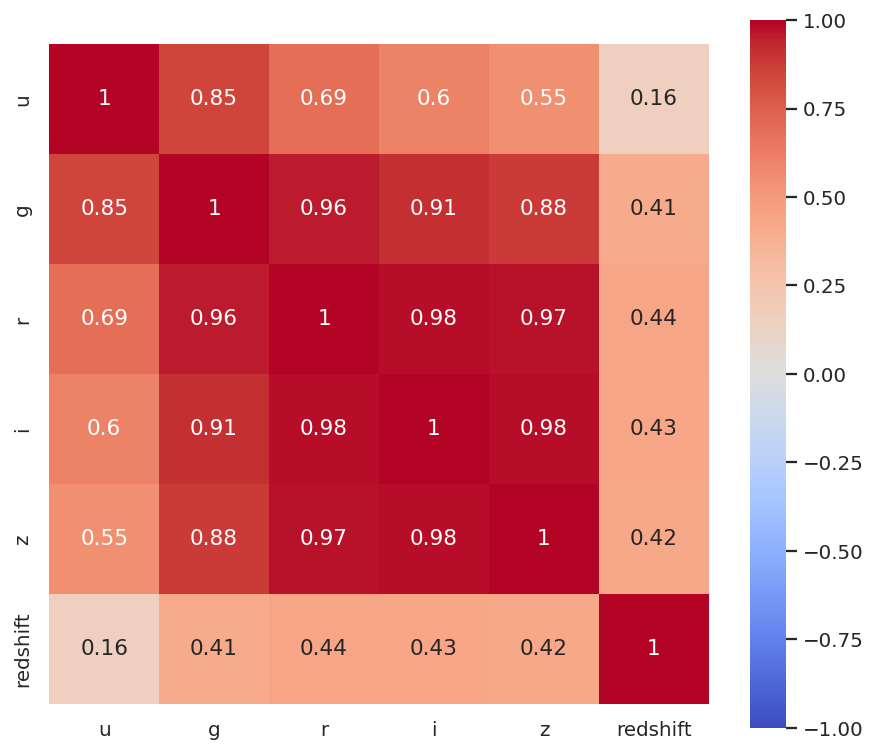

In [8]:
photo_red_cols = ['u', 'g', 'r', 'i', 'z', 'redshift']
corr_photo_red = sdss[photo_red_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_photo_red, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.tight_layout()
plt.show()

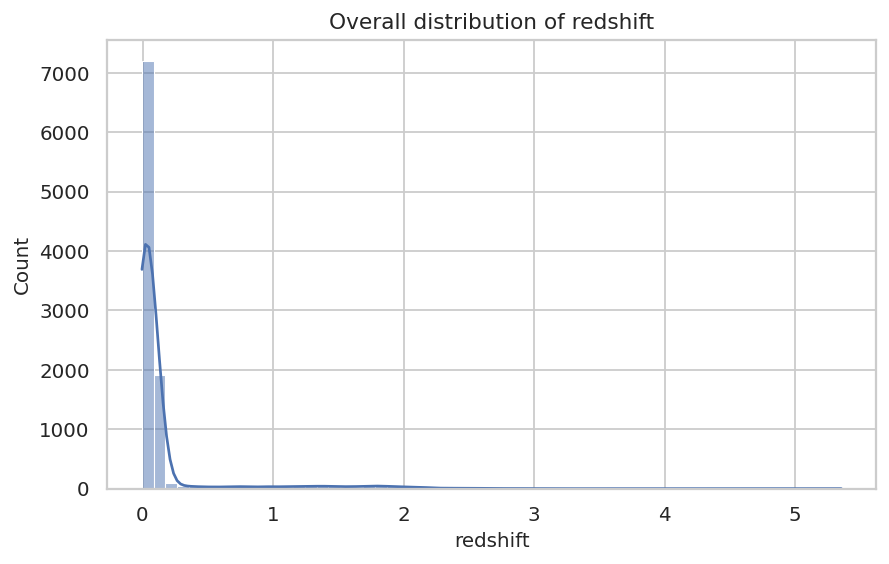

In [9]:
# redshift overall distribution
plt.figure(figsize=(7, 4.5))
sns.histplot(sdss['redshift'], bins=60, kde=True)
plt.title("Overall distribution of redshift")
plt.tight_layout()
plt.show()

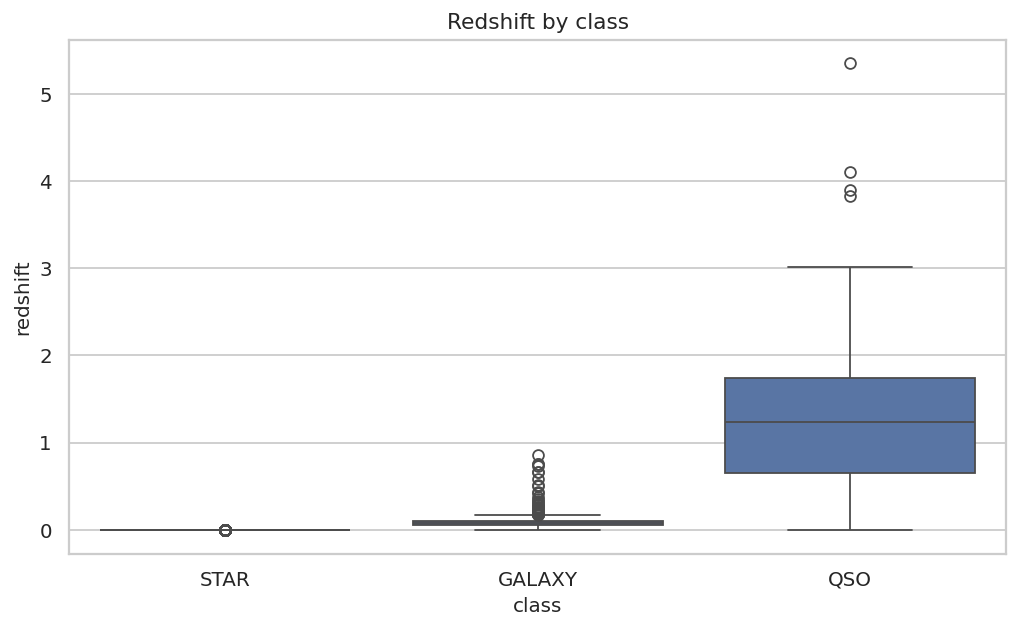

In [10]:
# redshift distribution by class
plt.figure(figsize=(8, 5))
sns.boxplot(data=sdss, x='class', y='redshift')
plt.title("Redshift by class")
plt.tight_layout()
plt.show()

In [11]:
eda_summary = sdss[['u', 'g', 'r', 'i', 'z', 'redshift']].agg(['mean', 'std', 'min', 'median', 'max']).T
eda_summary

,mean,std,min,median,max
u,18.619355,0.828656,12.988970,18.853095,19.599900
g,17.371931,0.945457,12.799550,17.495135,19.918970
r,16.840963,1.067764,12.431600,16.858770,24.802040
i,16.583579,1.141805,11.947210,16.554985,28.179630
z,16.422833,1.203188,11.610410,16.389945,22.833060
redshift,0.143726,0.388774,-0.004136,0.042591,5.353854


normality check

In [12]:
from scipy.linalg import inv
from scipy.stats import chi2, norm

mvn_cols = ['u', 'g', 'r', 'i', 'z']

X_mvn = sdss[mvn_cols].copy()

# Standardize
scaler_mvn = StandardScaler()
Z_mvn = scaler_mvn.fit_transform(X_mvn)

n, p = Z_mvn.shape
print(f"n = {n}, p = {p}")

n = 10000, p = 5


In [13]:
def mardia_test(X):
    """
    Mardia's multivariate skewness and kurtosis test.
    X should be standardized or at least continuous numeric data.
    Returns a dictionary of test statistics.
    """
    X = np.asarray(X)
    n, p = X.shape

    mean_vec = X.mean(axis=0)
    S = np.cov(X, rowvar=False)
    S_inv = np.linalg.inv(S)

    X_centered = X - mean_vec

    # Mahalanobis inner product matrix
    D = X_centered @ S_inv @ X_centered.T

    # Mardia skewness
    b1p = np.sum(D**3) / (n**2)

    # Mardia kurtosis
    di = np.sum((X_centered @ S_inv) * X_centered, axis=1)
    b2p = np.mean(di**2)

    # Skewness test statistic
    k = p * (p + 1) * (p + 2) / 6
    skew_stat = n * b1p / 6
    skew_p = 1 - chi2.cdf(skew_stat, df=k)

    # Kurtosis z-score
    expected_b2p = p * (p + 2)
    var_b2p = (8 * p * (p + 2)) / n
    z_kurt = (b2p - expected_b2p) / np.sqrt(var_b2p)
    kurt_p = 2 * (1 - norm.cdf(abs(z_kurt)))

    return {
        "n": n,
        "p": p,
        "mardia_skewness": b1p,
        "skewness_chi_square": skew_stat,
        "skewness_df": k,
        "skewness_p_value": skew_p,
        "mardia_kurtosis": b2p,
        "kurtosis_z": z_kurt,
        "kurtosis_p_value": kurt_p
    }

mardia_results = mardia_test(Z_mvn)

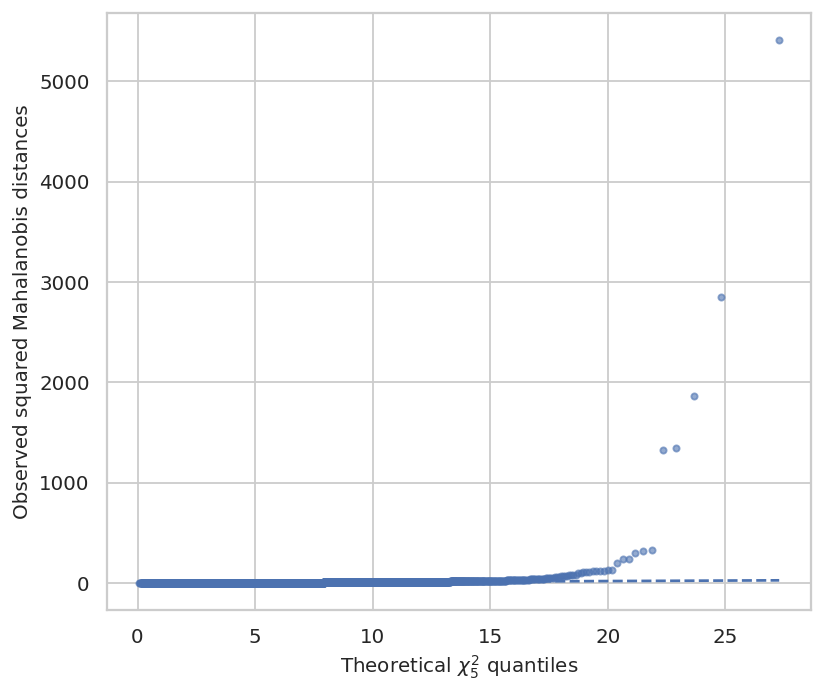

In [14]:
# Mean and covariance on standardized data
mean_vec = Z_mvn.mean(axis=0)
cov_mat = np.cov(Z_mvn, rowvar=False)
cov_inv = np.linalg.inv(cov_mat)

# Squared Mahalanobis distances
centered = Z_mvn - mean_vec
md2 = np.sum((centered @ cov_inv) * centered, axis=1)

# Sort observed and theoretical quantiles
md2_sorted = np.sort(md2)
theoretical_q = chi2.ppf((np.arange(1, n + 1) - 0.5) / n, df=p)

plt.figure(figsize=(6.5, 5.5))
plt.scatter(theoretical_q, md2_sorted, s=12, alpha=0.6)
plt.plot(
    [theoretical_q.min(), theoretical_q.max()],
    [theoretical_q.min(), theoretical_q.max()],
    linestyle='--'
)
plt.xlabel(r"Theoretical $\chi^2_5$ quantiles")
plt.ylabel("Observed squared Mahalanobis distances")
plt.tight_layout()
plt.show()

In [15]:
# flag possible outliers
cutoff_975 = chi2.ppf(0.975, df=p)
cutoff_999 = chi2.ppf(0.999, df=p)

n_out_975 = np.sum(md2 > cutoff_975)
n_out_999 = np.sum(md2 > cutoff_999)

print(f"97.5% cutoff: {cutoff_975:.3f}, flagged points: {n_out_975}")
print(f"99.9% cutoff: {cutoff_999:.3f}, flagged points: {n_out_999}")

97.5% cutoff: 12.833, flagged points: 364
99.9% cutoff: 20.515, flagged points: 99


In [16]:
mvn_summary = pd.DataFrame({
    "Statistic": [
        "Mardia skewness",
        "Skewness chi-square",
        "Skewness df",
        "Skewness p-value",
        "Mardia kurtosis",
        "Kurtosis z",
        "Kurtosis p-value"
    ],
    "Value": [
        mardia_results["mardia_skewness"],
        mardia_results["skewness_chi_square"],
        mardia_results["skewness_df"],
        mardia_results["skewness_p_value"],
        mardia_results["mardia_kurtosis"],
        mardia_results["kurtosis_z"],
        mardia_results["kurtosis_p_value"]
    ]
})

mvn_summary

,Statistic,Value
0,Mardia skewness,3.028881e+03
1,Skewness chi-square,5.048136e+06
2,Skewness df,3.500000e+01
3,Skewness p-value,0.000000e+00
4,Mardia kurtosis,4.541587e+03
5,Kurtosis z,2.693201e+04
6,Kurtosis p-value,0.000000e+00


PCA

In [17]:
# Main feature block for PCA
pca_cols = ['u', 'g', 'r', 'i', 'z']

# Standardize before PCA
scaler = StandardScaler()
X_pca = scaler.fit_transform(sdss[pca_cols])

# Fit PCA
pca = PCA()
scores = pca.fit_transform(X_pca)

# Basic outputs
explained_var = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_
cum_explained_ratio = np.cumsum(explained_ratio)
loadings = pca.components_.T

In [18]:
pca_summary = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, len(pca_cols) + 1)],
    "Eigenvalue": explained_var,
    "Proportion of Variance": explained_ratio,
    "Cumulative Proportion": cum_explained_ratio
})

pca_summary

,PC,Eigenvalue,Proportion of Variance,Cumulative Proportion
0,PC1,4.376529,0.875218,0.875218
1,PC2,0.576196,0.115228,0.990446
2,PC3,0.025260,0.005051,0.995497
3,PC4,0.016604,0.003320,0.998818
4,PC5,0.005911,0.001182,1.000000


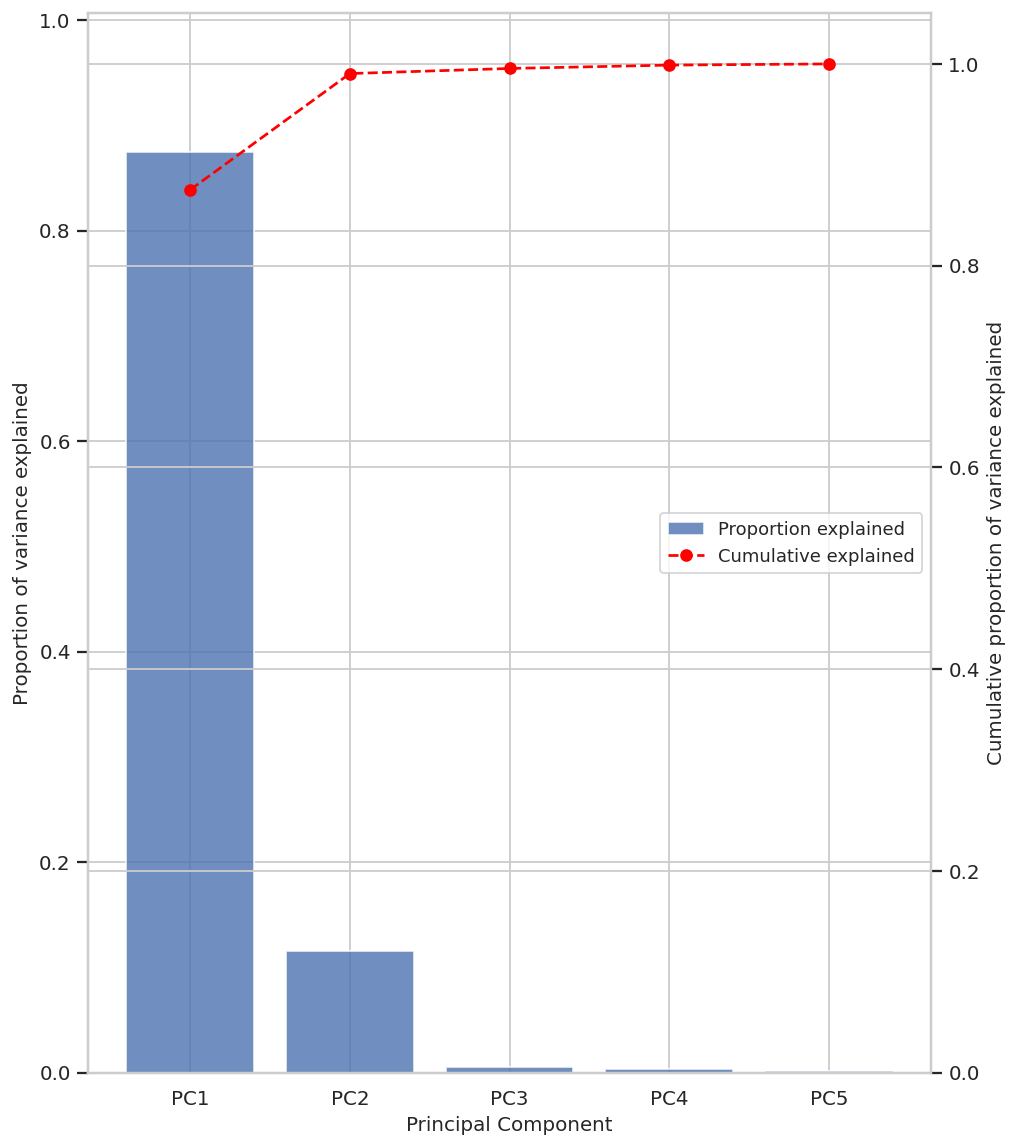

In [19]:
prop_var = explained_ratio
cum_var = np.cumsum(explained_ratio)
pc_labels = [f"PC{i}" for i in range(1, len(prop_var) + 1)]
x = np.arange(1, len(prop_var) + 1)

fig, ax1 = plt.subplots(figsize=(8, 9))

# Bar plot for explained variance
ax1.bar(x, prop_var, alpha=0.8, label='Proportion explained')
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Proportion of variance explained")
ax1.set_xticks(x)
ax1.set_xticklabels(pc_labels)
ax1.set_ylim(0, max(prop_var) * 1.15)

# Line plot for cumulative explained variance
ax2 = ax1.twinx()
ax2.plot(x, cum_var, marker='o', linestyle='--', label='Cumulative explained', color="red")
ax2.set_ylabel("Cumulative proportion of variance explained")
ax2.set_ylim(0, 1.05)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()

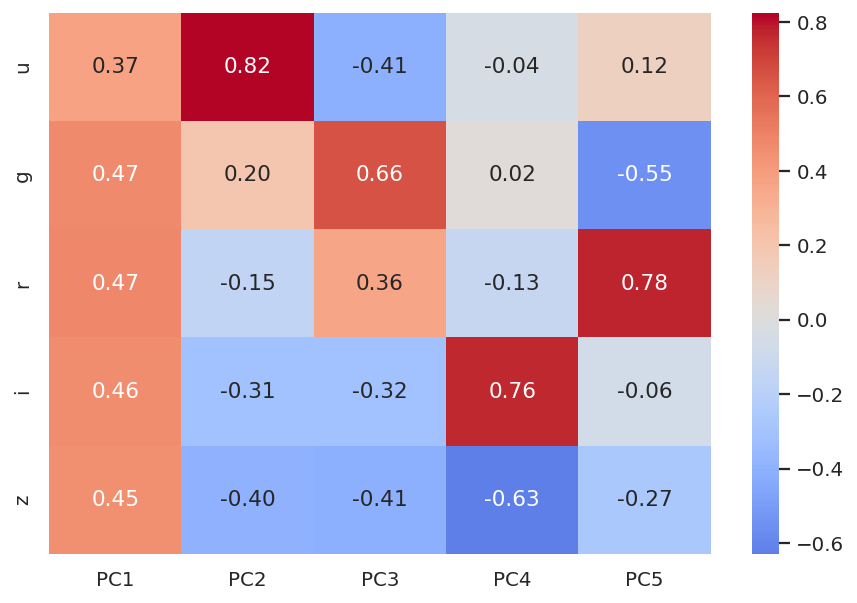

In [20]:
loadings_df = pd.DataFrame(
    loadings,
    index=pca_cols,
    columns=[f"PC{i}" for i in range(1, len(pca_cols) + 1)]
)

plt.figure(figsize=(7, 4.8))
sns.heatmap(loadings_df, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.tight_layout()
plt.show()

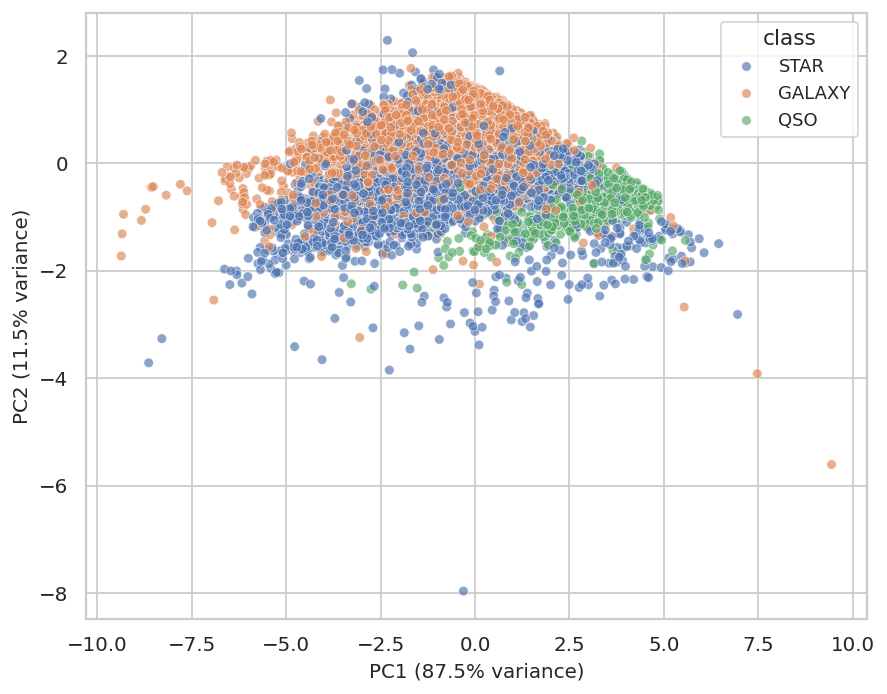

In [21]:
scores_df = pd.DataFrame(
    scores[:, :5],
    columns=[f"PC{i}" for i in range(1, 6)]
)

scores_df["class"] = sdss["class"].values

pc1_var = explained_ratio[0] * 100
pc2_var = explained_ratio[1] * 100

plt.figure(figsize=(7, 5.5))
sns.scatterplot(
    data=scores_df,
    x="PC1", y="PC2",
    hue="class",
    alpha=0.65,
    s=28
)
plt.xlabel(f"PC1 ({pc1_var:.1f}% variance)")
plt.ylabel(f"PC2 ({pc2_var:.1f}% variance)")
plt.tight_layout()
plt.show()

unsupervised clustering

In [22]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from sklearn.cluster import KMeans

# Use first two PCs for clustering
X_gmm = scores_df[['PC1', 'PC2']].values

# Keep labels for later comparison only
y_true = scores_df['class'].values

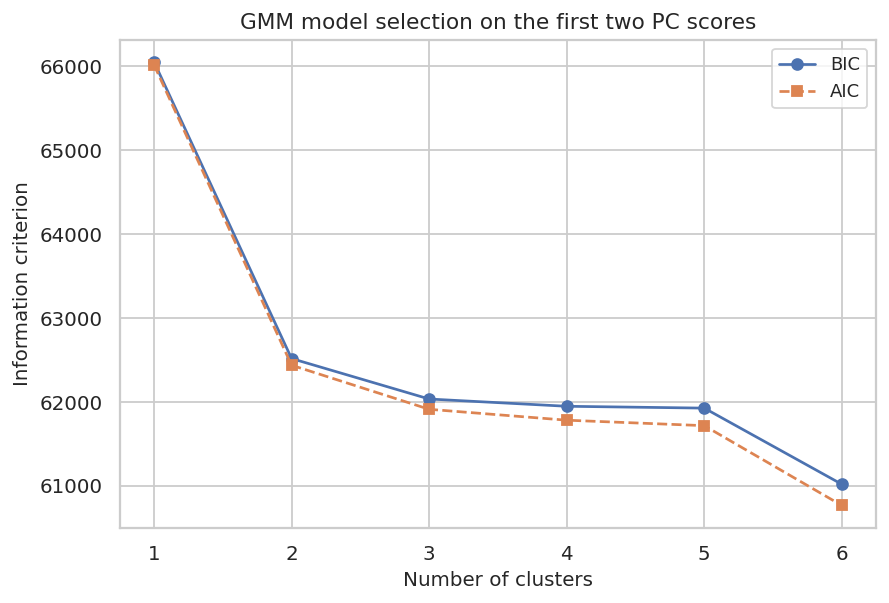

In [23]:
k_values = range(1, 7)
bic_vals = []
aic_vals = []

for k in k_values:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=437
    )
    gmm.fit(X_gmm)
    bic_vals.append(gmm.bic(X_gmm))
    aic_vals.append(gmm.aic(X_gmm))

plt.figure(figsize=(7, 4.8))
plt.plot(list(k_values), bic_vals, marker='o', label='BIC')
plt.plot(list(k_values), aic_vals, marker='s', linestyle='--', label='AIC')
plt.xlabel("Number of clusters")
plt.ylabel("Information criterion")
plt.title("GMM model selection on the first two PC scores")
plt.xticks(list(k_values))
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
gmm3 = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=437
)
gmm3.fit(X_gmm)

gmm_labels = gmm3.predict(X_gmm)
gmm_probs = gmm3.predict_proba(X_gmm)

scores_df['gmm_cluster'] = gmm_labels
scores_df[['PC1', 'PC2', 'class', 'gmm_cluster']].head()

,PC1,PC2,class,gmm_cluster
0,-1.063661,1.605619,STAR,0
1,-0.181554,0.070793,STAR,1
2,1.375966,0.574447,GALAXY,0
3,-1.504058,-0.574015,STAR,2
4,-1.147961,-1.290891,STAR,2


In [25]:
print("Cluster weights:")
print(np.round(gmm3.weights_, 3))

print("\nCluster means in PC space:")
print(pd.DataFrame(
    np.round(gmm3.means_, 3),
    columns=['PC1', 'PC2']
))

Cluster weights:
[0.374 0.381 0.244]

Cluster means in PC space:
     PC1    PC2
0  1.610  0.203
1 -0.021  0.067
2 -2.434 -0.416


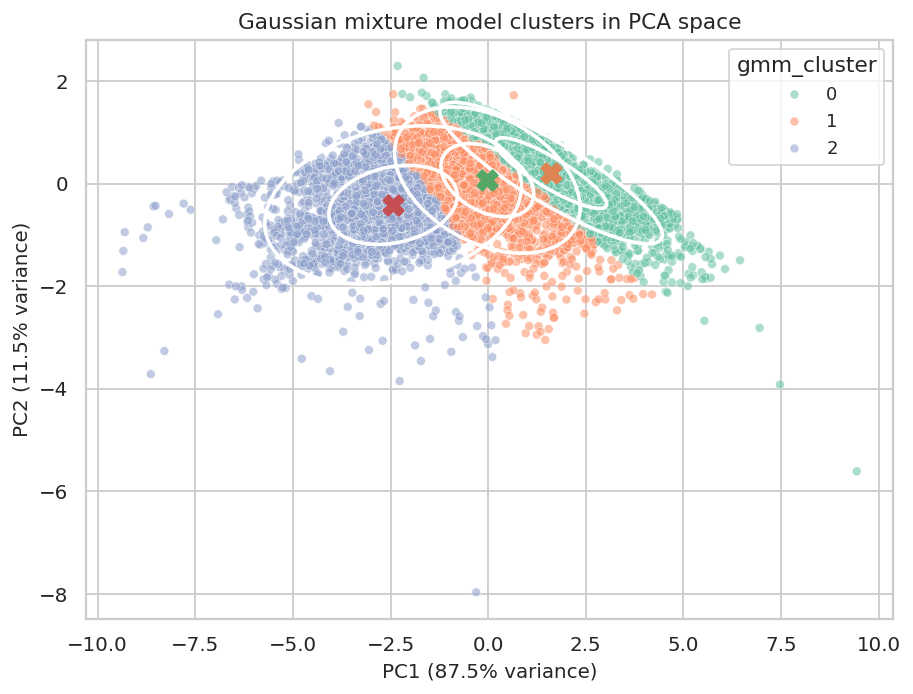

In [26]:
from matplotlib.patches import Ellipse

def draw_gmm_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()

    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)

    for nsig in [1, 2]:
        ax.add_patch(Ellipse(
            position,
            nsig * width,
            nsig * height,
            angle=angle,
            fill=False,
            **kwargs
        ))


fig, ax = plt.subplots(figsize=(7.2, 5.5))

sns.scatterplot(
    data=scores_df,
    x='PC1', y='PC2',
    hue='gmm_cluster',
    palette='Set2',
    alpha=0.55,
    s=24,
    ax=ax
)

for k in range(3):
    draw_gmm_ellipse(
        gmm3.means_[k],
        gmm3.covariances_[k],
        ax=ax,
        linewidth=2
    )
    ax.scatter(
        gmm3.means_[k, 0],
        gmm3.means_[k, 1],
        marker='X',
        s=130
    )

ax.set_xlabel(f"PC1 ({explained_ratio[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_ratio[1]*100:.1f}% variance)")
ax.set_title("Gaussian mixture model clusters in PCA space")
plt.tight_layout()
plt.show()

In [27]:
cluster_class_table = pd.crosstab(
    scores_df['gmm_cluster'],
    scores_df['class'],
    rownames=['GMM cluster'],
    colnames=['True class']
)

cluster_class_table

True class,GALAXY,QSO,STAR
GMM cluster,,,
0,2417,647,1292
1,1835,182,1540
2,746,21,1320


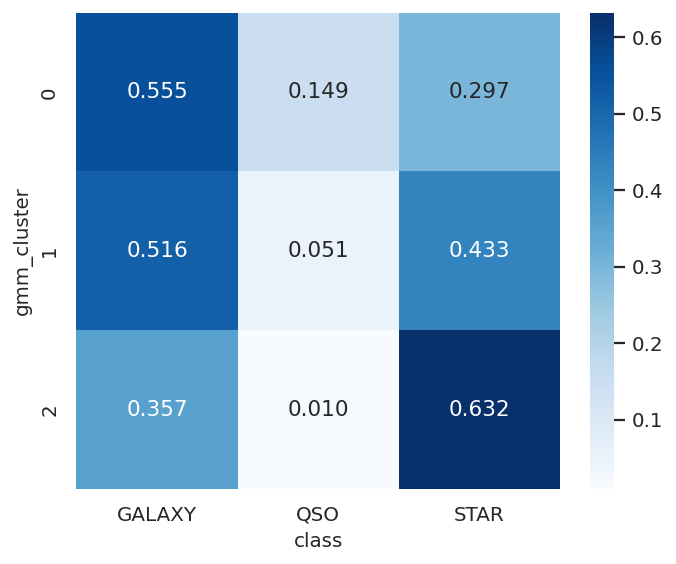

In [28]:
cluster_class_prop = pd.crosstab(
    scores_df['gmm_cluster'],
    scores_df['class'],
    normalize='index'
).round(3)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cluster_class_prop, annot=True, cmap='Blues', fmt=".3f")
plt.tight_layout()
plt.show()

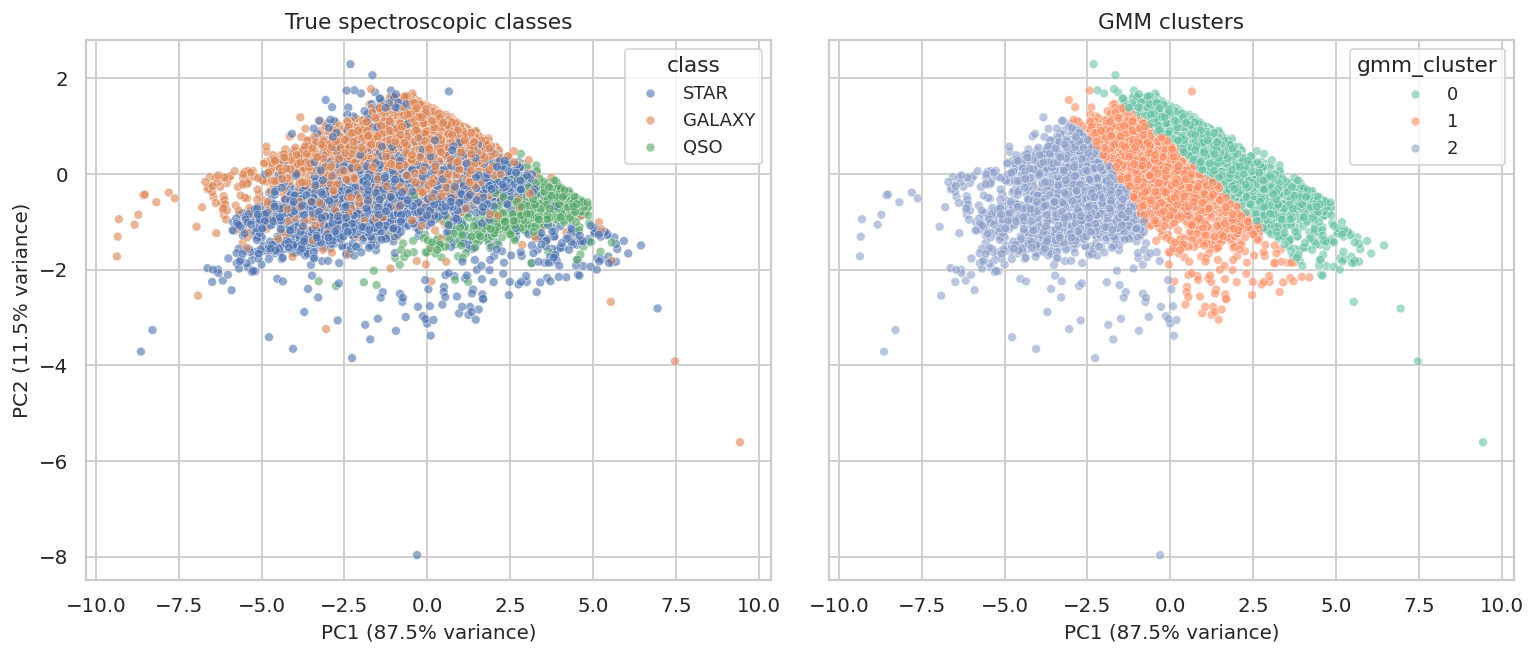

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True, sharey=True)

sns.scatterplot(
    data=scores_df,
    x='PC1', y='PC2',
    hue='class',
    alpha=0.6,
    s=24,
    ax=axes[0]
)
axes[0].set_title("True spectroscopic classes")
axes[0].set_xlabel(f"PC1 ({explained_ratio[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({explained_ratio[1]*100:.1f}% variance)")

sns.scatterplot(
    data=scores_df,
    x='PC1', y='PC2',
    hue='gmm_cluster',
    palette='Set2',
    alpha=0.6,
    s=24,
    ax=axes[1]
)
axes[1].set_title(f"GMM clusters")
axes[1].set_xlabel(f"PC1 ({explained_ratio[0]*100:.1f}% variance)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [30]:
# compare with k means

kmeans3 = KMeans(n_clusters=3, random_state=437, n_init=20)
kmeans_labels = kmeans3.fit_predict(X_gmm)

scores_df['kmeans_cluster'] = kmeans_labels

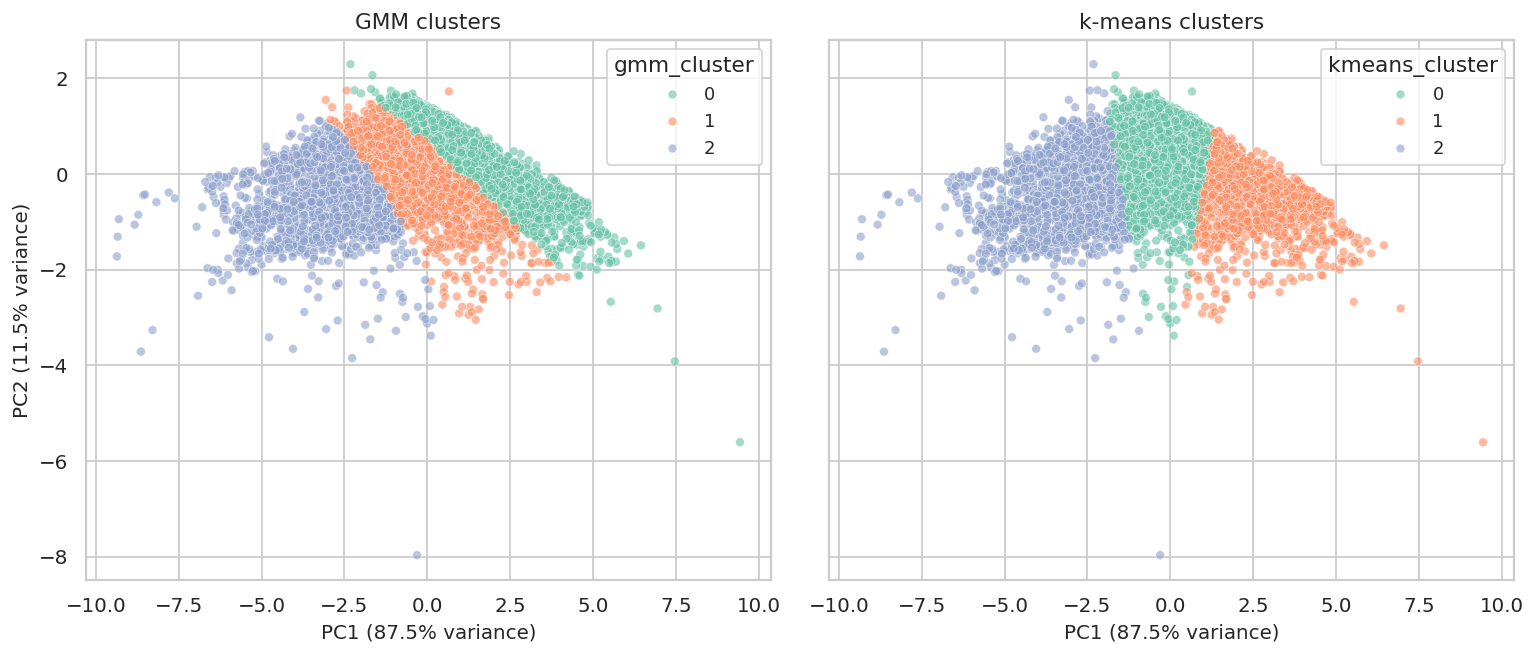

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True, sharey=True)

sns.scatterplot(
    data=scores_df,
    x='PC1', y='PC2',
    hue='gmm_cluster',
    palette='Set2',
    alpha=0.6,
    s=24,
    ax=axes[0]
)
axes[0].set_title(f"GMM clusters")
axes[0].set_xlabel(f"PC1 ({explained_ratio[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({explained_ratio[1]*100:.1f}% variance)")

sns.scatterplot(
    data=scores_df,
    x='PC1', y='PC2',
    hue='kmeans_cluster',
    palette='Set2',
    alpha=0.6,
    s=24,
    ax=axes[1]
)
axes[1].set_title(f"k-means clusters")
axes[1].set_xlabel(f"PC1 ({explained_ratio[0]*100:.1f}% variance)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

supervised classification

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

In [33]:
photo_cols = ['u', 'g', 'r', 'i', 'z']
photo_red_cols = ['u', 'g', 'r', 'i', 'z', 'redshift']

X_photo = sdss[photo_cols].copy()
X_photo_red = sdss[photo_red_cols].copy()
y = sdss['class'].copy()

print(y.value_counts())

class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64


In [34]:
X_train_photo, X_test_photo, y_train, y_test = train_test_split(
    X_photo, y,
    test_size=0.25,
    random_state=437,
    stratify=y
)

X_train_photo_red, X_test_photo_red, y_train_red, y_test_red = train_test_split(
    X_photo_red, y,
    test_size=0.25,
    random_state=437,
    stratify=y
)

print("Photometric only train shape:", X_train_photo.shape)
print("Photometric only test shape:", X_test_photo.shape)
print("\nTrain class proportions:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).round(3))

Photometric only train shape: (7500, 5)
Photometric only test shape: (2500, 5)

Train class proportions:
class
GALAXY    0.500
STAR      0.415
QSO       0.085
Name: proportion, dtype: float64

Test class proportions:
class
GALAXY    0.500
STAR      0.415
QSO       0.085
Name: proportion, dtype: float64


In [35]:
logit_photo = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=2000,
        random_state=437
    ))
])

logit_photo.fit(X_train_photo, y_train)

y_pred_logit_photo = logit_photo.predict(X_test_photo)

print("Photometric only logistic regression accuracy:",
      round(accuracy_score(y_test, y_pred_logit_photo), 4))

print("\nClassification report: photometric only logistic regression")
print(classification_report(y_test, y_pred_logit_photo, digits=3))

Photometric only logistic regression accuracy: 0.9336

Classification report: photometric only logistic regression
              precision    recall  f1-score   support

      GALAXY      0.960     0.922     0.941      1249
         QSO      0.917     0.887     0.902       213
        STAR      0.908     0.957     0.932      1038

    accuracy                          0.934      2500
   macro avg      0.928     0.922     0.925      2500
weighted avg      0.935     0.934     0.934      2500



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


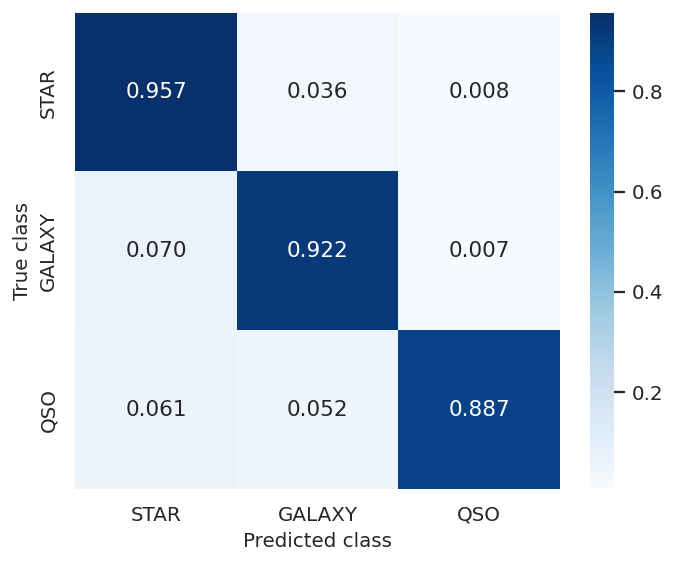

In [36]:
class_order = ['STAR', 'GALAXY', 'QSO']

cm_logit_photo = confusion_matrix(
    y_test, y_pred_logit_photo,
    labels=class_order,
    normalize='true'
)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm_logit_photo,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order
)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

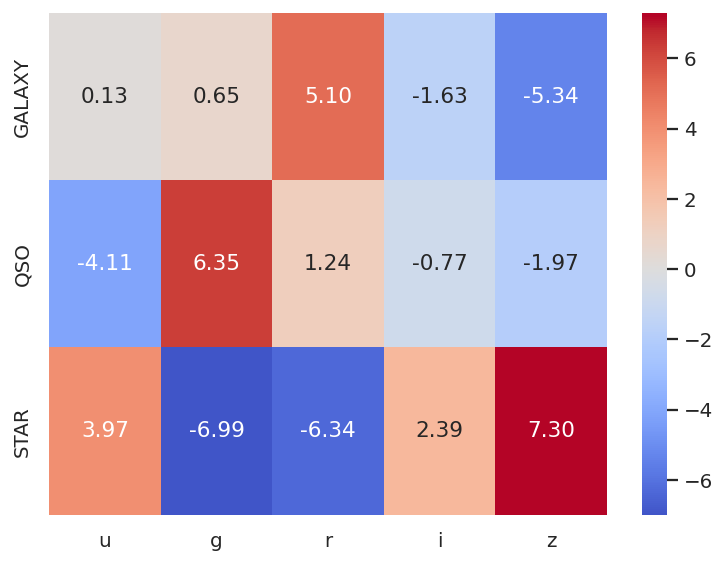

In [37]:
logit_model = logit_photo.named_steps['model']
coef_df = pd.DataFrame(
    logit_model.coef_,
    index=logit_model.classes_,
    columns=photo_cols
)

plt.figure(figsize=(6, 4.5))
sns.heatmap(coef_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.tight_layout()
plt.show()

In [38]:
lda_photo = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearDiscriminantAnalysis())
])

lda_photo.fit(X_train_photo, y_train)

y_pred_lda_photo = lda_photo.predict(X_test_photo)

print("Photometric only LDA accuracy:",
      round(accuracy_score(y_test, y_pred_lda_photo), 4))

print("\nClassification report: photometric only LDA")
print(classification_report(y_test, y_pred_lda_photo, digits=3))

Photometric only LDA accuracy: 0.9268

Classification report: photometric only LDA
              precision    recall  f1-score   support

      GALAXY      0.951     0.921     0.936      1249
         QSO      0.918     0.892     0.905       213
        STAR      0.901     0.941     0.921      1038

    accuracy                          0.927      2500
   macro avg      0.923     0.918     0.920      2500
weighted avg      0.928     0.927     0.927      2500



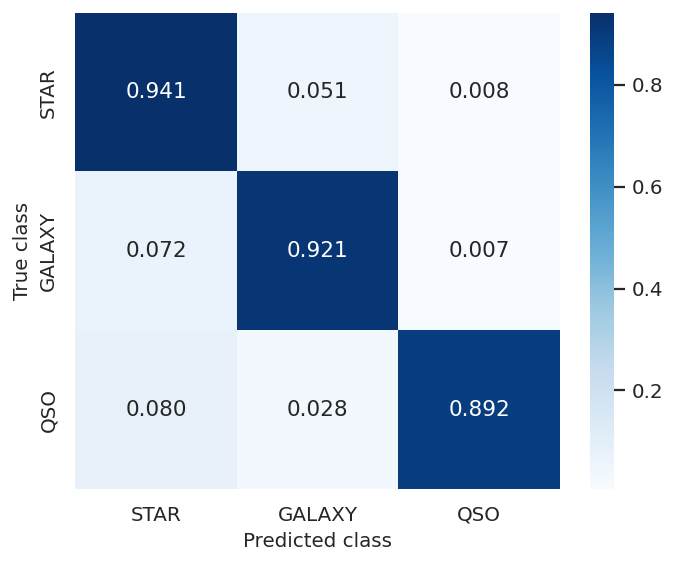

In [39]:
cm_lda_photo = confusion_matrix(
    y_test, y_pred_lda_photo,
    labels=class_order,
    normalize='true'
)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm_lda_photo,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order
)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

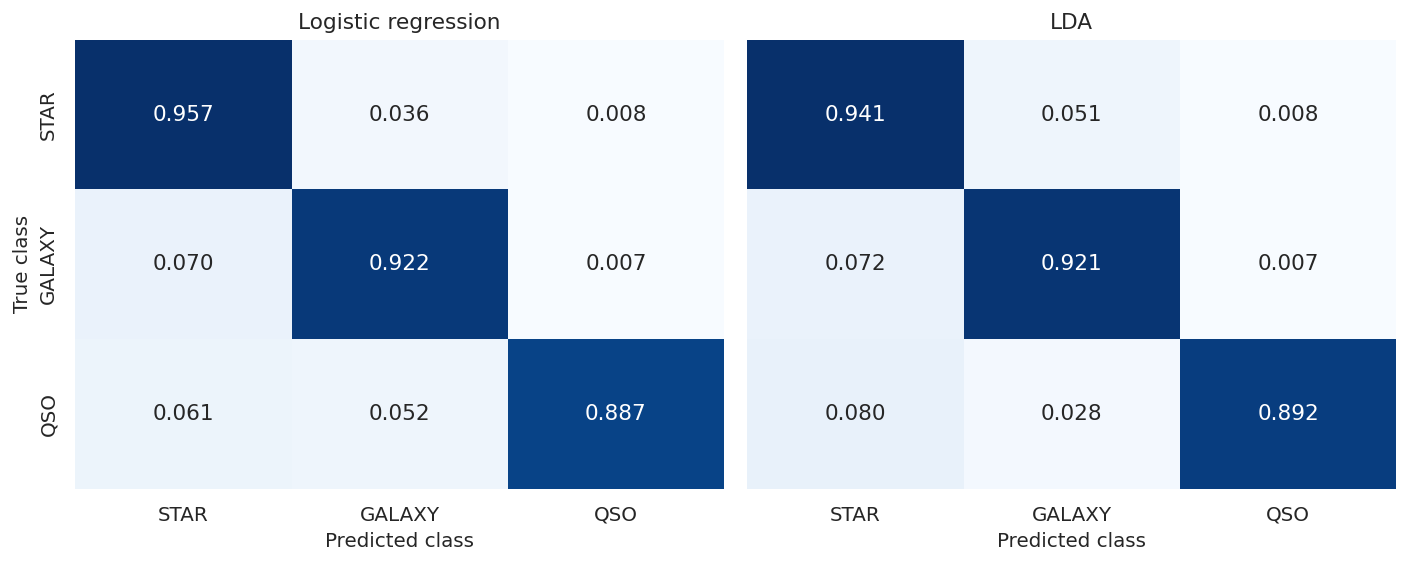

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

sns.heatmap(
    cm_logit_photo,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order,
    ax=axes[0],
    cbar=False
)
axes[0].set_title("Logistic regression")
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("True class")

sns.heatmap(
    cm_lda_photo,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order,
    ax=axes[1],
    cbar=False
)
axes[1].set_title("LDA")
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [41]:
logit_photo_red = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=2000,
        random_state=437
    ))
])

logit_photo_red.fit(X_train_photo_red, y_train_red)

y_pred_logit_photo_red = logit_photo_red.predict(X_test_photo_red)

print("Photometric + redshift logistic regression accuracy:",
      round(accuracy_score(y_test_red, y_pred_logit_photo_red), 4))

print("\nClassification report: photometric + redshift logistic regression")
print(classification_report(y_test_red, y_pred_logit_photo_red, digits=3))

Photometric + redshift logistic regression accuracy: 0.972

Classification report: photometric + redshift logistic regression
              precision    recall  f1-score   support

      GALAXY      0.988     0.957     0.972      1249
         QSO      0.976     0.948     0.962       213
        STAR      0.953     0.995     0.974      1038

    accuracy                          0.972      2500
   macro avg      0.972     0.967     0.969      2500
weighted avg      0.973     0.972     0.972      2500



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [42]:
lda_photo_red = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearDiscriminantAnalysis())
])

lda_photo_red.fit(X_train_photo_red, y_train_red)

y_pred_lda_photo_red = lda_photo_red.predict(X_test_photo_red)

print("Photometric + redshift LDA accuracy:",
      round(accuracy_score(y_test_red, y_pred_lda_photo_red), 4))

print("\nClassification report: photometric + redshift LDA")
print(classification_report(y_test_red, y_pred_lda_photo_red, digits=3))

Photometric + redshift LDA accuracy: 0.9224

Classification report: photometric + redshift LDA
              precision    recall  f1-score   support

      GALAXY      0.923     0.926     0.924      1249
         QSO      0.994     0.746     0.853       213
        STAR      0.912     0.954     0.932      1038

    accuracy                          0.922      2500
   macro avg      0.943     0.876     0.903      2500
weighted avg      0.924     0.922     0.922      2500



In [43]:
cm_logit_photo_red = confusion_matrix(
    y_test_red, y_pred_logit_photo_red,
    labels=class_order,
    normalize='true'
)

cm_lda_photo_red = confusion_matrix(
    y_test_red, y_pred_lda_photo_red,
    labels=class_order,
    normalize='true'
)

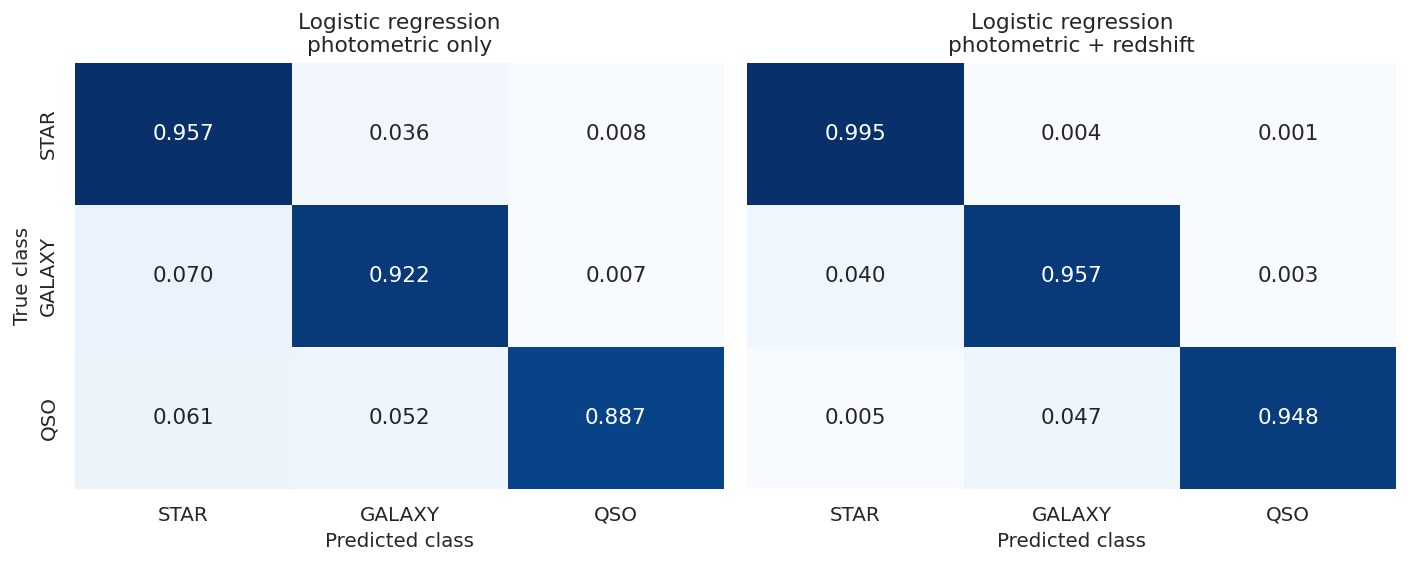

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

sns.heatmap(
    cm_logit_photo,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order,
    ax=axes[0],
    cbar=False
)
axes[0].set_title("Logistic regression\nphotometric only")
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("True class")

sns.heatmap(
    cm_logit_photo_red,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order,
    ax=axes[1],
    cbar=False
)
axes[1].set_title("Logistic regression\nphotometric + redshift")
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [45]:
from sklearn.metrics import classification_report, accuracy_score

class_order = ['STAR', 'GALAXY', 'QSO']

def get_model_summary(y_true, y_pred, model_name, feature_set):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Model': model_name,
        'Feature set': feature_set,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Recall (STAR)': report['STAR']['recall'],
        'Recall (GALAXY)': report['GALAXY']['recall'],
        'Recall (QSO)': report['QSO']['recall']
    }

summary_rows = [
    get_model_summary(y_test, y_pred_logit_photo, 'Logistic regression', 'Photometric only'),
    get_model_summary(y_test, y_pred_lda_photo, 'LDA', 'Photometric only'),
    get_model_summary(y_test_red, y_pred_logit_photo_red, 'Logistic regression', 'Photometric + redshift'),
    get_model_summary(y_test_red, y_pred_lda_photo_red, 'LDA', 'Photometric + redshift')
]

classification_summary = pd.DataFrame(summary_rows)
classification_summary.round(3)

,Model,Feature set,Accuracy,Recall (STAR),Recall (GALAXY),Recall (QSO)
0,Logistic regression,Photometric only,0.934,0.957,0.922,0.887
1,LDA,Photometric only,0.927,0.941,0.921,0.892
2,Logistic regression,Photometric + redshift,0.972,0.995,0.957,0.948
3,LDA,Photometric + redshift,0.922,0.954,0.926,0.746


robustness check

In [46]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [47]:
photo_cols = ['u', 'g', 'r', 'i', 'z']
photo_red_cols = ['u', 'g', 'r', 'i', 'z', 'redshift']

X_photo = sdss[photo_cols].copy()
X_photo_red = sdss[photo_red_cols].copy()
y = sdss['class'].copy()

In [48]:
logit_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=2000,
        random_state=437
    ))
])

lda_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearDiscriminantAnalysis())
])

In [49]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=437)

scoring = {
    'accuracy': 'accuracy',
    'recall_star': 'recall_macro'  # placeholder, overwritten below
}

In [50]:
from sklearn.metrics import make_scorer, recall_score

scoring = {
    'accuracy': 'accuracy',
    'recall_star': make_scorer(recall_score, average=None, labels=['STAR']),
    'recall_galaxy': make_scorer(recall_score, average=None, labels=['GALAXY']),
    'recall_qso': make_scorer(recall_score, average=None, labels=['QSO'])
}
def recall_for_class(target_class):
    def scorer(y_true, y_pred):
        y_true_bin = (np.array(y_true) == target_class).astype(int)
        y_pred_bin = (np.array(y_pred) == target_class).astype(int)
        return recall_score(y_true_bin, y_pred_bin)
    return make_scorer(scorer)

scoring = {
    'accuracy': 'accuracy',
    'recall_star': recall_for_class('STAR'),
    'recall_galaxy': recall_for_class('GALAXY'),
    'recall_qso': recall_for_class('QSO')
}

In [51]:
cv_results = {}

cv_results['Logistic regression | Photometric only'] = cross_validate(
    logit_model, X_photo, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

cv_results['LDA | Photometric only'] = cross_validate(
    lda_model, X_photo, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

cv_results['Logistic regression | Photometric + redshift'] = cross_validate(
    logit_model, X_photo_red, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

cv_results['LDA | Photometric + redshift'] = cross_validate(
    lda_model, X_photo_red, y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

In [52]:
rows = []

for name, result in cv_results.items():
    model_name, feature_set = name.split(' | ')
    rows.append({
        'Model': model_name,
        'Feature set': feature_set,
        'Accuracy (mean)': np.mean(result['test_accuracy']),
        'Accuracy (sd)': np.std(result['test_accuracy'], ddof=1),
        'Recall STAR (mean)': np.mean(result['test_recall_star']),
        'Recall STAR (sd)': np.std(result['test_recall_star'], ddof=1),
        'Recall GALAXY (mean)': np.mean(result['test_recall_galaxy']),
        'Recall GALAXY (sd)': np.std(result['test_recall_galaxy'], ddof=1),
        'Recall QSO (mean)': np.mean(result['test_recall_qso']),
        'Recall QSO (sd)': np.std(result['test_recall_qso'], ddof=1)
    })

robustness_summary = pd.DataFrame(rows)
robustness_summary.round(3)

,Model,Feature set,Accuracy (mean),Accuracy (sd),Recall STAR (mean),Recall STAR (sd),Recall GALAXY (mean),Recall GALAXY (sd),Recall QSO (mean),Recall QSO (sd)
0,Logistic regression,Photometric only,0.933,0.001,0.954,0.003,0.926,0.006,0.871,0.028
1,LDA,Photometric only,0.921,0.003,0.929,0.006,0.923,0.006,0.871,0.031
2,Logistic regression,Photometric + redshift,0.971,0.002,0.994,0.002,0.958,0.006,0.941,0.022
3,LDA,Photometric + redshift,0.921,0.006,0.947,0.007,0.927,0.004,0.756,0.049


In [53]:
robustness_summary_pct = robustness_summary.copy()

metric_cols = [
    'Accuracy (mean)', 'Accuracy (sd)',
    'Recall STAR (mean)', 'Recall STAR (sd)',
    'Recall GALAXY (mean)', 'Recall GALAXY (sd)',
    'Recall QSO (mean)', 'Recall QSO (sd)'
]

for col in metric_cols:
    robustness_summary_pct[col] = (robustness_summary_pct[col] * 100).round(1)

robustness_summary_pct

,Model,Feature set,Accuracy (mean),Accuracy (sd),Recall STAR (mean),Recall STAR (sd),Recall GALAXY (mean),Recall GALAXY (sd),Recall QSO (mean),Recall QSO (sd)
0,Logistic regression,Photometric only,93.3,0.1,95.4,0.3,92.6,0.6,87.1,2.8
1,LDA,Photometric only,92.1,0.3,92.9,0.6,92.3,0.6,87.1,3.1
2,Logistic regression,Photometric + redshift,97.1,0.2,99.4,0.2,95.8,0.6,94.1,2.2
3,LDA,Photometric + redshift,92.1,0.6,94.7,0.7,92.7,0.4,75.6,4.9


In [54]:
robustness_summary_short = robustness_summary.copy()

robustness_summary_short['Accuracy'] = (
    robustness_summary_short['Accuracy (mean)'].round(3).astype(str)
    + ' ± ' +
    robustness_summary_short['Accuracy (sd)'].round(3).astype(str)
)

robustness_summary_short['Recall (STAR)'] = (
    robustness_summary_short['Recall STAR (mean)'].round(3).astype(str)
    + ' ± ' +
    robustness_summary_short['Recall STAR (sd)'].round(3).astype(str)
)

robustness_summary_short['Recall (GALAXY)'] = (
    robustness_summary_short['Recall GALAXY (mean)'].round(3).astype(str)
    + ' ± ' +
    robustness_summary_short['Recall GALAXY (sd)'].round(3).astype(str)
)

robustness_summary_short['Recall (QSO)'] = (
    robustness_summary_short['Recall QSO (mean)'].round(3).astype(str)
    + ' ± ' +
    robustness_summary_short['Recall QSO (sd)'].round(3).astype(str)
)

robustness_summary_short = robustness_summary_short[
    ['Model', 'Feature set', 'Accuracy', 'Recall (STAR)', 'Recall (GALAXY)', 'Recall (QSO)']
]

robustness_summary_short

,Model,Feature set,Accuracy,Recall (STAR),Recall (GALAXY),Recall (QSO)
0,Logistic regression,Photometric only,0.933 ± 0.001,0.954 ± 0.003,0.926 ± 0.006,0.871 ± 0.028
1,LDA,Photometric only,0.921 ± 0.003,0.929 ± 0.006,0.923 ± 0.006,0.871 ± 0.031
2,Logistic regression,Photometric + redshift,0.971 ± 0.002,0.994 ± 0.002,0.958 ± 0.006,0.941 ± 0.022
3,LDA,Photometric + redshift,0.921 ± 0.006,0.947 ± 0.007,0.927 ± 0.004,0.756 ± 0.049
